In [1]:
# Representa e manipula matrizes
import numpy as np
# Exibe as imagens
import matplotlib.pyplot as plt
# Processamento de Imagens e Visão Computacional
import cv2

import pandas as pd


# Ler, converter, e redimensionar imagens
from PIL import Image
# Acessa imagens de exemplo
from skimage import data, color, util

In [2]:
def mostrar_imagem(imagem, titulo, cmap=None, barra_cores=False, tamanho=(4,4)):
    # Definindo Tamanho da imagem
    plt.figure(figsize=tamanho);

    plt.imshow(imagem, cmap=cmap, vmin=0, vmax=255)
    plt.title(titulo)
    plt.axis("off")

    if barra_cores:
        plt.colorbar()

    plt.show()

def mostrar_comparacao(imagens, titulos, cmaps=None, tamanho=(16, 6)):
    quantidade = len(imagens)

    if cmaps is None:
        cmaps = [None] * quantidade

    fig, eixos = plt.subplots(1, quantidade, figsize=tamanho)

    if quantidade == 1:
        eixos = [eixos]

    for eixo, imagem, titulo, cmap in zip(eixos, imagens, titulos, cmaps):
        eixo.imshow(imagem, cmap=cmap)
        eixo.set_title(titulo)
        eixo.axis("off")

    plt.tight_layout()
    plt.show()

def mostrar_imagem_histograma(imagem, titulo="Imagem"):
    fig, eixos = plt.subplots(1, 2, figsize=(16,6))

    eixos[0].imshow(imagem, cmap='gray', vmin=0, vmax=255)
    eixos[0].set_title(titulo)
    eixos[0].axis("off")

    eixos[1].hist(
        imagem.ravel(),
        bins = 256,
        range = (0, 255)
    )
    eixos[1].set_title("Histograma")
    eixos[1].set_xlabel("Intensidade")
    eixos[1].set_ylabel("Quantidade de Pixels")

    plt.show()

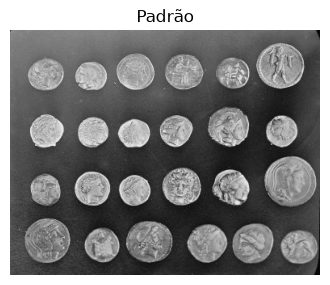

In [3]:
imagem_moedas = data.coins()

mostrar_imagem(
    imagem_moedas,
    titulo='Padrão',
    cmap="gray"
)

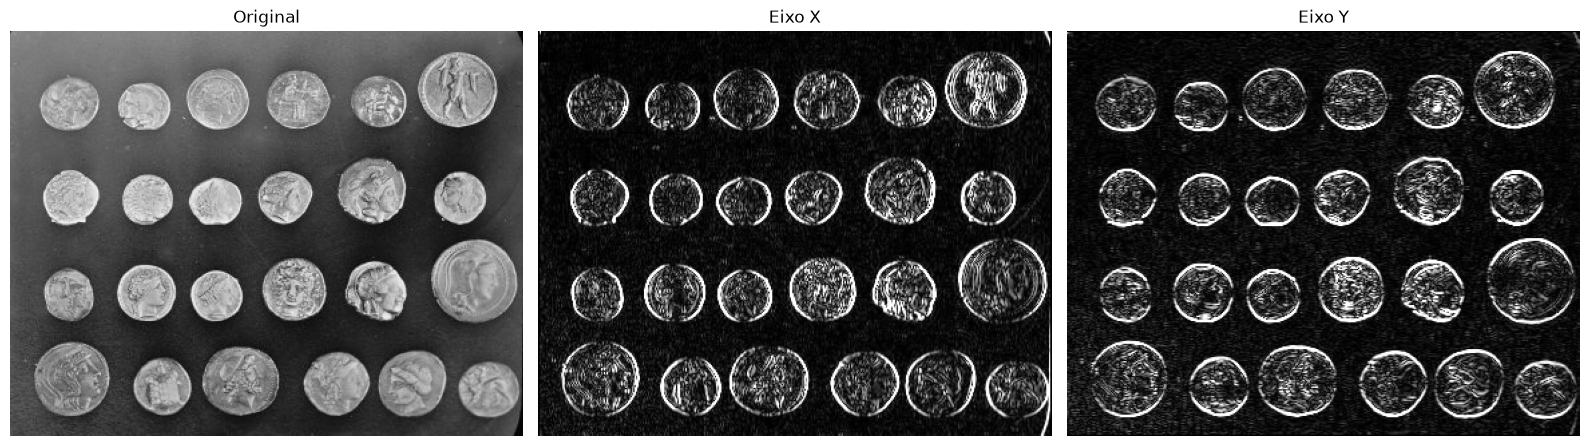

In [4]:
# [-1 0 1]
# [-2 0 2]
# [-1 0 1]

sobel_x = cv2.Sobel(
    imagem_moedas, # Imagem
    cv2.CV_64F, # Permite valores decimais e negativos
    1, # Direção X 
    0, # Direção Y
    ksize=3 # Tamanho do kernel
)

sobel_y = cv2.Sobel(
    imagem_moedas,
    cv2.CV_64F,
    0,
    1,
    ksize=3
)

# convertScaleAbs - Pegar valor Absuluto
# Converte para faixa de 0 a 255
# Converter para uint8
sobel_x_abs = cv2.convertScaleAbs(sobel_x)
sobel_y_abs = cv2.convertScaleAbs(sobel_y) 

mostrar_comparacao(
    [imagem_moedas, sobel_x_abs, sobel_y_abs],
    ['Original', 'Eixo X','Eixo Y'],
    ['gray'] * 3
)

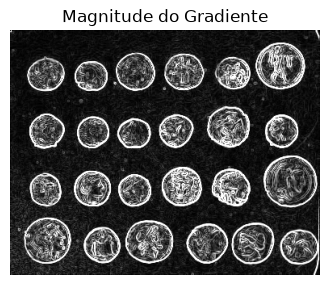

In [6]:
magnitude_sobel = np.sqrt(
    sobel_x ** 2 +
    sobel_y ** 2
)

magnitude_sobel = np.clip(
    magnitude_sobel,
    0,
    255
).astype(np.uint8)

mostrar_imagem(
    magnitude_sobel,
    'Magnitude do Gradiente',
    cmap='gray'
)

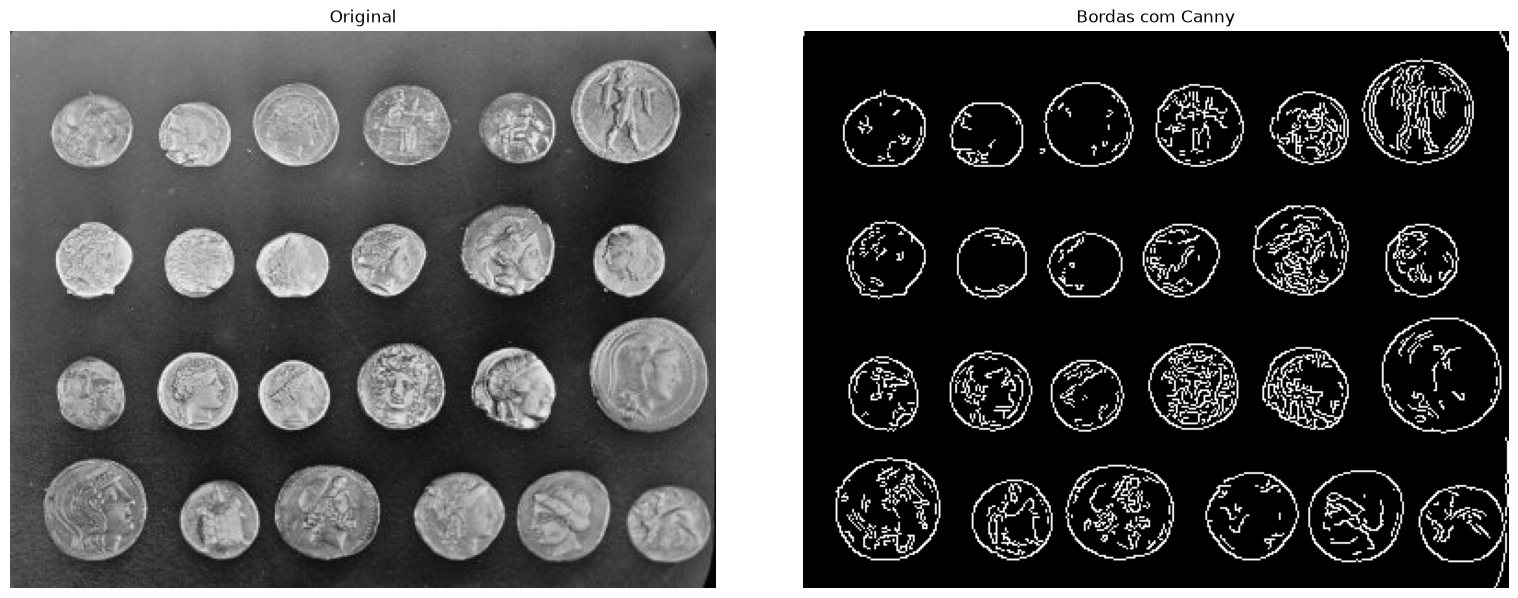

In [10]:
# 1º Suavizar a imagem
# 2º Calculo Gradientes
# 3º Deixar as bordas finas
# 4º Aplicação de dois limeares
# 5º Conexão das bordas 
bordas_canny = cv2.Canny(
    imagem_moedas,
    150,
    250,
)

mostrar_comparacao(
    [imagem_moedas, bordas_canny],
    ["Original", "Bordas com Canny"],
    ['gray'] * 2
)